# 01 — EDA: Mersey River streamflow

**Goal of this notebook:**
1. Find the real Water Survey of Canada (WSC) gauge station on the Mersey River (or a nearby NS run-of-river candidate)
2. Pull its historical daily discharge (m3/s) record
3. Explore seasonality, gaps, and ice-affected readings before we build any model

Data source: Water Survey of Canada (ECCC), via the public `wateroffice.ec.gc.ca` web services and the `api.weather.gc.ca` (MSC GeoMet) station metadata API. Both are free, no API key required.

In [1]:
# --- imports ---
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## Step 1 — find the gauge station

We query the MSC GeoMet OGC API for hydrometric stations inside a Nova Scotia bounding box, then
filter locally for anything with "MERSEY" in the name. Filtering client-side (instead of trying to
guess the exact query-param syntax the API expects) keeps this robust even if the API's filtering
options change.

In [2]:
# rough bounding box around mainland Nova Scotia (lon_min, lat_min, lon_max, lat_max)
NS_BBOX = "-66.5,43.3,-59.5,47.1"

STATIONS_URL = "https://api.weather.gc.ca/collections/hydrometric-stations/items"

params = {
    "bbox": NS_BBOX,
    "f": "json",       # ask for GeoJSON
    "limit": 1000,      # NS doesn't have anywhere near 1000 stations, so this grabs them all
}

resp = requests.get(STATIONS_URL, params=params, timeout=30)
resp.raise_for_status()
geojson = resp.json()

# flatten the GeoJSON features into a plain dataframe
records = []
for feature in geojson["features"]:
    props = feature["properties"]
    lon, lat = feature["geometry"]["coordinates"]
    records.append({**props, "LONGITUDE": lon, "LATITUDE": lat})

ns_stations = pd.DataFrame(records)
print(f"Pulled {len(ns_stations)} NS-area stations")
ns_stations.head()

Pulled 240 NS-area stations


,STATION_NAME,IDENTIFIER,STATION_NUMBER,PROV_TERR_STATE_LOC,STATUS_EN,STATUS_FR,CONTRIBUTOR_EN,CONTRIBUTOR_FR,VERTICAL_DATUM,REAL_TIME,RHBN,DRAINAGE_AREA_GROSS,DRAINAGE_AREA_EFFECT,LONGITUDE,LATITUDE
0,CASTAWAY STREAM NEAR CASTAWAY,01AN001,01AN001,NB,Discontinued,Fermée,,,ASSUMED DATUM,0,0,39.459999,None,-65.711937,46.298328
1,SALMON RIVER AT CASTAWAY,01AN002,01AN002,NB,Active,En service,NEW BRUNSWICK DEPARTMENT OF THE ENVIRONMENT,MINISTERE DE L'ENVIRONNEMENT DU NOUVEAU-BRUNSWICK,ASSUMED DATUM,1,0,1045.000000,None,-65.722748,46.290722
2,SAINT JOHN RIVER AT OROMOCTO,01AO001,01AO001,NB,Discontinued,Fermée,,,ASSUMED DATUM,0,0,44660.000000,None,-66.472221,45.855560
3,SAINT JOHN RIVER AT MAUGERVILLE,01AO002,01AO002,NB,Active,En service,NEW BRUNSWICK DEPARTMENT OF THE ENVIRONMENT,MINISTERE DE L'ENVIRONNEMENT DU NOUVEAU-BRUNSWICK,GEODETIC SURVEY OF CANADA DATUM,1,0,44660.000000,None,-66.453171,45.866470
4,GRAND LAKE AT NEWCASTLE CREEK,01AO003,01AO003,NB,Active,En service,NEW BRUNSWICK DEPARTMENT OF THE ENVIRONMENT,MINISTERE DE L'ENVIRONNEMENT DU NOUVEAU-BRUNSWICK,GEODETIC SURVEY OF CANADA DATUM,1,0,2963.000000,None,-66.003220,46.056889


In [3]:
# filter for candidate river names — widen this search if Mersey turns out to have
# no active discharge station (some gauges are water-level only)
name_col = "STATION_NAME" if "STATION_NAME" in ns_stations.columns else [
    c for c in ns_stations.columns if "NAME" in c.upper()
][0]

candidates = ns_stations[
    ns_stations[name_col].str.contains("MERSEY|TUSKET|ROSEWAY|MEDWAY", case=False, na=False)
]
candidates[[name_col, "STATION_NUMBER", "LATITUDE", "LONGITUDE"]]

,STATION_NAME,STATION_NUMBER,LATITUDE,LONGITUDE
167,TUSKET RIVER AT TUSKET FALLS,01EA001,43.881390,-65.973892
168,TUSKET RIVER (WEST BRANCH) AT REYNARD BRIDGE,01EA002,43.927780,-65.933327
169,TUSKET RIVER AT WILSON'S BRIDGE,01EA003,43.924561,-65.868439
170,ROSEWAY RIVER AT LOWER OHIO,01EC001,43.837360,-65.369110
172,MERSEY RIVER AT INDIAN GARDENS,01ED001,44.161388,-65.008614
173,MERSEY RIVER AT LOWER GREAT BROOK FALLS,01ED002,44.090000,-64.845833
174,MERSEY RIVER AT MILTON,01ED003,44.066669,-64.764999
175,MERSEY RIVER BELOW GEORGE LAKE,01ED005,44.333141,-65.205078
177,MERSEY RIVER BELOW MILL FALLS,01ED007,44.436779,-65.221863
183,MEDWAY RIVER AT CHARLESTON,01EE001,44.173328,-64.660004


Pick the station that matches the Mersey River watershed (the Roseway/Medway/Tusket names are
backups if the Mersey gauge is discontinued or water-level-only). Once you've confirmed the right
one from the printed table above, hardcode it below — this becomes our single source of truth for
the rest of the project.

In [4]:
# fill this in once step 1 confirms the correct station number, e.g. "01EO001"
STATION_NUMBER = "01ED003"

## Step 2 — pull historical daily discharge

WSC's bulk CSV service returns daily mean discharge for a station over a date range.
`parameters[]=47` is the discharge parameter code (46 would be water level).

In [11]:
def fetch_daily_discharge(station_number: str, start_date: str, end_date: str) -> pd.DataFrame:
    """
    Pull daily mean discharge (m3/s) for one WSC station over a date range.

    station_number : WSC station id, e.g. "01ED003"
    start_date/end_date : "YYYY-MM-DD"
    """
    url = "https://wateroffice.ec.gc.ca/services/daily_data/csv/inline"
    params = {
        "stations[]": station_number,
        "parameters[]": "flow",  # discharge
        "start_date": start_date,
        "end_date": end_date,
    }
    resp = requests.get(url, params=params, timeout=60)
    resp.raise_for_status()

    # strip a leading byte-order-mark (BOM) if present, then find the header row
    # by content ("Date" + "Value" both present) rather than a fixed prefix,
    # since WSC prepends a metadata preamble before the actual data table
    text = resp.text.lstrip("\ufeff")
    lines = text.splitlines()
    header_idx = next(i for i, line in enumerate(lines) if "Date" in line and "Value" in line)
    csv_body = "\n".join(lines[header_idx:])

    df = pd.read_csv(StringIO(csv_body))
    return df


# pull the full available record — adjust start_date once you see how far back this station goes
raw = fetch_daily_discharge(STATION_NUMBER, start_date="1954-01-01", end_date="1979-06-30")
raw.head()

,ID,Date,Parameter/Paramètre,Value/Valeur,Symbol/Symbole
0,01ED003,1954-12-17,discharge/débit,69.4,NaN
1,01ED003,1954-12-18,discharge/débit,69.9,NaN
2,01ED003,1954-12-19,discharge/débit,41.6,NaN
3,01ED003,1954-12-20,discharge/débit,68.2,NaN
4,01ED003,1954-12-21,discharge/débit,70.2,NaN


In [10]:
ns_stations[ns_stations["STATION_NUMBER"] == "01ED003"]


,STATION_NAME,IDENTIFIER,STATION_NUMBER,PROV_TERR_STATE_LOC,STATUS_EN,STATUS_FR,CONTRIBUTOR_EN,CONTRIBUTOR_FR,VERTICAL_DATUM,REAL_TIME,RHBN,DRAINAGE_AREA_GROSS,DRAINAGE_AREA_EFFECT,LONGITUDE,LATITUDE
174,MERSEY RIVER AT MILTON,01ED003,01ED003,NS,Discontinued,Fermée,,,ASSUMED DATUM,0,0,1899.0,None,-64.764999,44.066669


In [7]:
import requests

url = "https://wateroffice.ec.gc.ca/services/daily_data/csv/inline"
params = {
    "stations[]": STATION_NUMBER,
    "parameters[]": "flow",
    "start_date": "1990-01-01",
    "end_date": "2026-08-18",
}
resp = requests.get(url, params=params, timeout=60)
print(resp.status_code)
print("\n".join(resp.text.splitlines()[:15]))  # first 15 lines only

200
﻿ ID,Date,Parameter/Paramètre,Value/Valeur,Symbol/Symbole


In [ ]:
# save the untouched pull before any cleaning — always keep a raw copy
raw.to_csv("../data/raw/mersey_daily_discharge_raw.csv", index=False)
print(f"Saved {len(raw)} rows to data/raw/")

## Step 3 — clean up and get a proper datetime index

The exact column names depend on what the CSV export calls them (varies slightly by station/era of
record) — print `raw.columns` above and adjust the rename map below to match what you actually got.

In [ ]:
print(raw.columns.tolist())

In [ ]:
# --- adjust this rename map once you've seen the real column names above ---
df = raw.rename(columns={
    "Date": "date",
    "Value/Valeur": "discharge_cms",
})[["date", "discharge_cms"]].copy()

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")

# quick gap check — how many days are missing vs. a full daily calendar
full_range = pd.date_range(df.index.min(), df.index.max(), freq="D")
missing_days = full_range.difference(df.index)
print(f"Record spans {df.index.min().date()} to {df.index.max().date()}")
print(f"{len(missing_days)} missing days out of {len(full_range)} ({len(missing_days)/len(full_range):.1%})")

## Step 4 — visualize seasonality

Expect a spring freshet (snowmelt) peak and a summer low-flow trough — this shape is exactly what
will make streamflow forecasting harder than the Load Forecasting project's demand data, since it's
driven by precipitation and snowpack rather than a stable daily/weekly human-activity cycle.

In [ ]:
fig, ax = plt.subplots()
df["discharge_cms"].plot(ax=ax, linewidth=0.6, color="#1D9E75")
ax.set_title("Daily mean discharge — full record")
ax.set_ylabel("discharge (m3/s)")
plt.show()

In [ ]:
# monthly distribution — shows the seasonal pattern clearly
monthly = df.copy()
monthly["month"] = monthly.index.month

fig, ax = plt.subplots()
sns.boxplot(data=monthly, x="month", y="discharge_cms", ax=ax, color="#85B7EB")
ax.set_title("Discharge by month — seasonal spread")
ax.set_xlabel("month")
ax.set_ylabel("discharge (m3/s)")
plt.show()

In [ ]:
# flow-duration curve — % of time flow is exceeded, this is the standard hydro-engineering
# view of a river's flow regime and will feed directly into the dashboard hero visual
sorted_flow = df["discharge_cms"].dropna().sort_values(ascending=False).reset_index(drop=True)
exceedance_pct = (sorted_flow.index + 1) / len(sorted_flow) * 100

fig, ax = plt.subplots()
ax.plot(exceedance_pct, sorted_flow, color="#378ADD", linewidth=1.2)
ax.set_title("Flow-duration curve")
ax.set_xlabel("% of time flow is exceeded")
ax.set_ylabel("discharge (m3/s)")
plt.show()

## Next steps

- [ ] Confirm the station choice and note its drainage area + years of record in the README later
- [ ] Check for ice-affected flags (WSC marks these — they matter for a Nova Scotia winter record)
- [ ] Move to `02_feature_engineering.ipynb`: lags, rolling means, month/season indicators, optional NASA POWER precip/temp as exogenous variables
- [ ] Commit this notebook + raw data pull to GitHub before starting feature engineering

In [12]:
raw.to_csv("../data/raw/mersey_daily_discharge_raw.csv", index=False)
print(f"Saved {len(raw)} rows to data/raw/")

Saved 8907 rows to data/raw/


In [13]:
print(raw.columns.tolist())

[' ID', 'Date', 'Parameter/Paramètre', 'Value/Valeur', 'Symbol/Symbole']


In [14]:
df = raw.rename(columns={
    "Date": "date",
    "Value/Valeur": "discharge_cms",
})[["date", "discharge_cms"]].copy()

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")

full_range = pd.date_range(df.index.min(), df.index.max(), freq="D")
missing_days = full_range.difference(df.index)
print(f"Record spans {df.index.min().date()} to {df.index.max().date()}")
print(f"{len(missing_days)} missing days out of {len(full_range)} ({len(missing_days)/len(full_range):.1%})")


Record spans 1954-12-17 to 1979-05-29
23 missing days out of 8930 (0.3%)


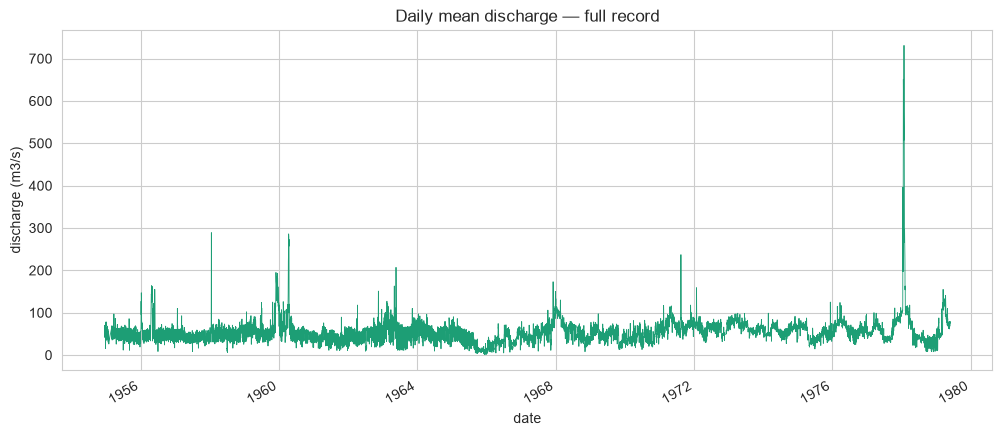

In [15]:
#seasonality plot
fig, ax = plt.subplots()
df["discharge_cms"].plot(ax=ax, linewidth=0.6, color="#1D9E75")
ax.set_title("Daily mean discharge — full record")
ax.set_ylabel("discharge (m3/s)")
plt.show()

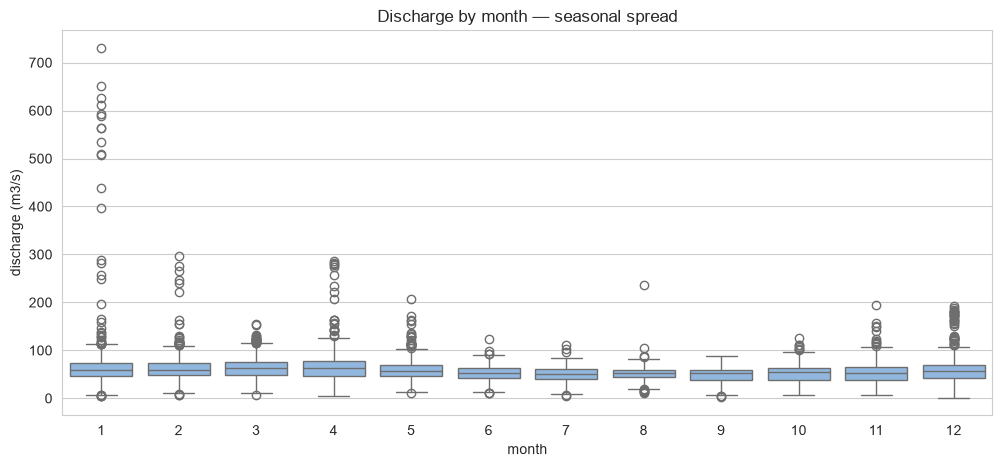

In [16]:
#monthly boxplot
monthly = df.copy()
monthly["month"] = monthly.index.month

fig, ax = plt.subplots()
sns.boxplot(data=monthly, x="month", y="discharge_cms", ax=ax, color="#85B7EB")
ax.set_title("Discharge by month — seasonal spread")
ax.set_xlabel("month")
ax.set_ylabel("discharge (m3/s)")
plt.show()

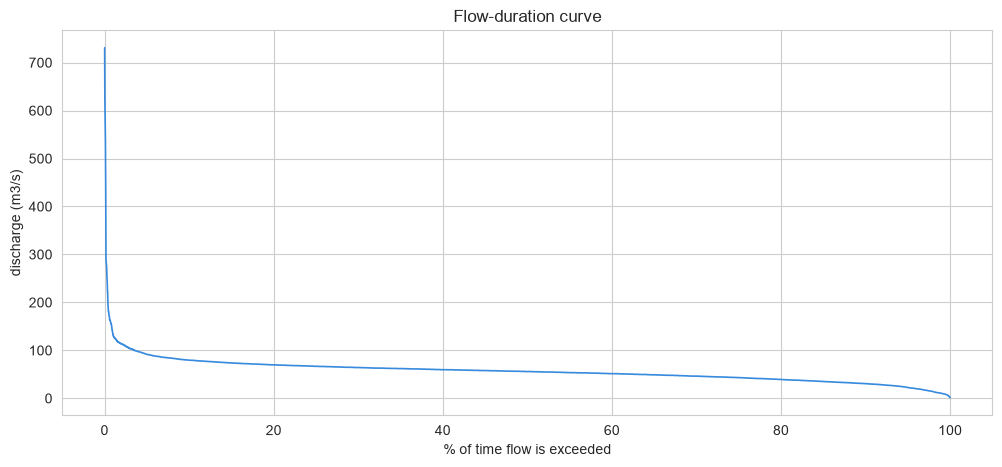

In [17]:
#flow duration curve
sorted_flow = df["discharge_cms"].dropna().sort_values(ascending=False).reset_index(drop=True)
exceedance_pct = (sorted_flow.index + 1) / len(sorted_flow) * 100

fig, ax = plt.subplots()
ax.plot(exceedance_pct, sorted_flow, color="#378ADD", linewidth=1.2)
ax.set_title("Flow-duration curve")
ax.set_xlabel("% of time flow is exceeded")
ax.set_ylabel("discharge (m3/s)")
plt.show()

In [18]:
raw["Symbol/Symbole"].value_counts(dropna=False)

Symbol/Symbole
NaN    8425
E       406
A        66
B        10
Name: count, dtype: int64